# Example
## Reisudal Box Plot as Fucntion of $x$ 

An example showing the use of ```inspect.boxplot_vx```. This function is used to visualize how a dataset $y$ is distrubted and varies as a function of a secondary dataset $x$. The SciPy ```stats.binned_statistic``` function is used to bin the dataset as a function $x$ and calculate the neccessary statistics as a function of $y$ for a box and whisker plot.

At each $x$ bin, box and whisker values are derived for $y$ which can be plotted using ```matplotlib.axes.Axes.bxp```.

```inspect.boxplot_vx``` can calculate box and whisker values for an arbitrary number of $x$ datasets which are passed as Pandas DataFrame.

```inspect.boxplot_vx``` was developed to investigate how model residuals (observations-predictions) vary as a function of model features. However it can be applied to any dataset to visualize how $y$ varies as a function $x$. 

The example here shows how model residuals vary as function of geomagnetic conditions as measured by AE and Sym-H. The model file ```RF_FI_GEO_OOS_CHAMP.hdf5``` contains the predicted and observed density along the CHAMP satellite orbit. The predicted density is from a random forest model of atmospheric neutral density at 400 km altitude. 



In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

path_dat = r"E:\OneDrive\Phys4501\data\RF_FI_GEO_OOS_CHAMP.hdf5"

In [3]:
import ml_fw.inspect as inspect
import ml_fw.plot as mlfw_plot

In [4]:
# load the data set and calculate the residuals
dat = pd.read_hdf(path_dat)
dat['resid'] = dat['400kmDensity']-dat['400kmDensity_pred']

In [5]:
# define the x_cols of dat that we want to use for binning
# and their ranges and number of bins
x_dat = ['AE', 'SYM_H index']
x_bin = [20,21]
x_range = [[0,2000], [-200,10]]
# the y_col to derive the stats
y_dat = ['resid']

whisker = 0 # don't want whiskers
showmean = True # plot the means

In [6]:
box_ref = inspect.boxplot_vx(dat[x_dat],dat[y_dat], whisker=0,
                           bins=x_bin,xrange=x_range) 

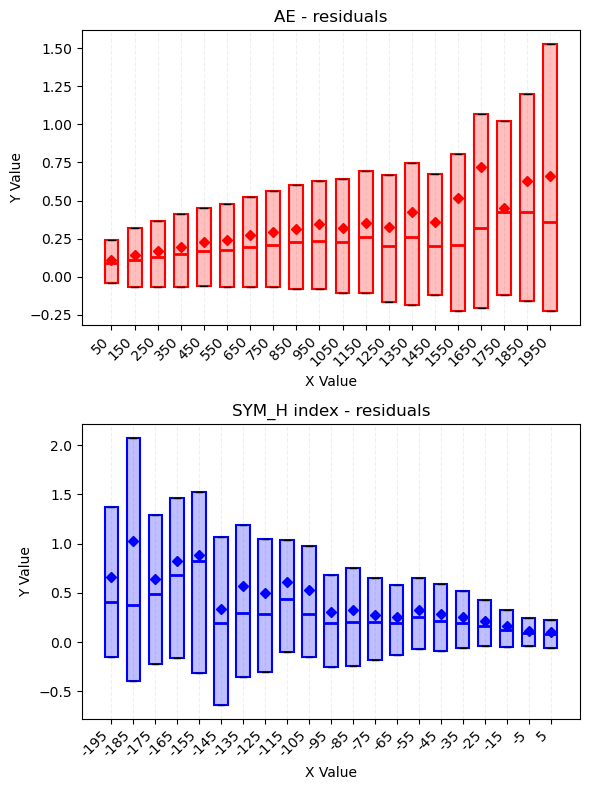

In [7]:
p = mlfw_plot.plot_boxplot(box_ref,figsize=(6,8), colors=['red', 'blue'],alphas=[0.25], 
                               separate_by='both')